In [ ]:
pip install transformers==4.43.4 trl==0.8.6 peft==0.11.1 accelerate bitsandbytes

In [ ]:
import os
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from huggingface_hub import login

In [ ]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
token = user_secrets.get_secret("token")

from huggingface_hub import login
login(token)

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

base_model_name = "meta-llama/Meta-Llama-3.1-8B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

In [ ]:
# Load base model
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

In [ ]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    base_model_name
)

# Attach the LoRA adapter
model = PeftModel.from_pretrained(
    base_model,
    "/kaggle/input/datasets/buketsak/llama-qlora/llama-qlora"
)

model.eval()

In [ ]:
import pandas as pd
df2 = pd.read_csv("/kaggle/input/datasets/buketsak/data2-nmt-analysis-detailed-corrected/data2_nmt_analysis_detailed_corrected.csv")
#df3 = pd.read_csv("/kaggle/input/datasets/buketsak/data3-nmt-analysis-n/data3_nmt_analysis.csv")

In [ ]:
if "finetuned-llama3.1-IT-8B" not in df2.columns:
    df2["finetuned-llama3.1-IT-8B"] = ""

In [ ]:
def translate(sentence):
    messages = [
        {
            "role": "system",
            "content": "You are a professional English to Turkish translator. "
        },
        {
            "role": "user",
            "content": f"Translate this sentence from English to Turkish:\n\nEnglish:{sentence}"
        }
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        add_special_tokens=False
    )
    inputs = inputs.to(model.device)
    attention_mask = torch.ones_like(inputs)

    with torch.no_grad():
        output = model.generate(
            input_ids=inputs,
            attention_mask=attention_mask, 
            max_new_tokens=64,
            do_sample=False,
            repetition_penalty=1.1,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_tokens = output[0][inputs.shape[-1]:]
    # Original decoded output
    original_decoded = tokenizer.decode(
        generated_tokens, 
        skip_special_tokens=True
    ).strip()

    # Cleaned version (first sentence only)
    cleaned_decoded = original_decoded
    if "." in original_decoded:
        cleaned_decoded = original_decoded.split(".", 1)[0] + "."

    return original_decoded, cleaned_decoded

In [ ]:
BATCH_SIZE = 25

# Create list to store original outputs
original_outputs = []

for i in range(0, len(df2), BATCH_SIZE):
    batch = df2.iloc[i:i + BATCH_SIZE]

    for idx, sentence in batch["source_sentence"].items():
        original_translation, cleaned_translation = translate(sentence)

        # Save cleaned version into main dataframe
        df2.at[idx, "finetuned-llama3.1-IT-8B"] = cleaned_translation

        # Save original version + source sentence separately
        original_outputs.append({
            "source_sentence": sentence,
            "original_finetuned_llama_translation": original_translation
        })

    torch.cuda.empty_cache()
    print(f"Processed rows {i}–{i + len(batch) - 1}")


In [ ]:
df2.to_csv("data_nmt_2_all3_finetuned.csv", index=False)

In [ ]:
df_original = pd.DataFrame(original_outputs)

df_original.to_csv("data_nmt_2_all3_original_outputs.csv", index=False)

In [ ]:
import pandas as pd
df3 = pd.read_csv("/kaggle/input/datasets/buketsak/data3-nmt-analysis-n1/data3_nmt_analysis.csv")

In [ ]:
if "finetuned-llama3.1-IT-8B" not in df3.columns:
    df3["finetuned-llama3.1-IT-8B"] = ""

In [ ]:
BATCH_SIZE = 25

# Create list to store original outputs for df3
original_outputs_df3 = []

for i in range(0, len(df3), BATCH_SIZE):
    batch = df3.iloc[i:i + BATCH_SIZE]

    for idx, sentence in batch["source_sentence"].items():
        original_translation, cleaned_translation = translate(sentence)

        # Save cleaned version into main dataframe
        df3.at[idx, "finetuned-llama3.1-IT-8B"] = cleaned_translation

        # Save original version separately (include row id for safety)
        original_outputs_df3.append({
            "source_sentence": sentence,
            "original_finetuned_llama_translation": original_translation
        })

    torch.cuda.empty_cache()
    print(f"Processed rows {i}–{i + len(batch) - 1}")

In [ ]:
df3.to_csv("data3_nmt_all_finetuned.csv", index=False)

In [ ]:
df3_original = pd.DataFrame(original_outputs_df3)

df3_original.to_csv("data_nmt_3_all3_original_outputs.csv", index=False)

# DF2 EVALUATION

In [2]:
import pandas as pd

In [3]:
!pip install stanza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 40.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.2/794.2 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 13.7 MB/s eta 0:00:00


In [4]:
df2  = pd.read_csv("/kaggle/input/datasets/buketsak/data-nmt-2-all3-finetuned-corrected/data_nmt_2_all3_finetuned_corrected.csv")

In [5]:
import stanza
stanza.download("tr")

Downloaded file to /root/.cache/stanza/1.14.0/resources/resources.json


models/default.zip:   0%|          | 0.00/338M [00:00<?, ?B/s]

Downloaded file to /root/.cache/stanza/1.14.0/resources/tr/default.zip
Finished downloading models and saved to /root/.cache/stanza/1.14.0/resources


[['zip', 'default.zip']]

In [6]:
nlp = stanza.Pipeline("tr", processors="tokenize,pos,mwt,lemma,depparse")

Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


Downloaded file to /root/.cache/stanza/1.14.0/resources/resources.json
Loading these models for language: tr (Turkish):
| Processor | Package       |
-----------------------------
| tokenize  | imst          |
| mwt       | imst          |
| pos       | imst_charlm   |
| lemma     | imst_nocharlm |
| depparse  | imst_charlm   |

Using device: cuda
Loading: tokenize
Loading: mwt
Loading: pos
Loading: lemma
Loading: depparse
Done loading processors!


In [7]:
def contains_onun(text):
    """Annotates data if there is "onun" in the output sentence by writing True or False"""
    if not isinstance(text, str):
        return False

    doc = nlp(text)
    for sent in doc.sentences:
        for word in sent.words:
            
            # must be subject
            #if word.deprel != "nsubj": (doesn't count some of "onun")
             #   continue
                
            if word.upos == "PRON" and word.feats:
                feats = word.feats.split("|")
                if "Case=Gen" in feats and "Person=3" in feats and "PronType=Prs" in feats and not any("Reflex=Yes" in f for f in feats): #reflex=yes corresponds "kendisini" in Turkish
                    return True
    return False

In [8]:
model_cols = ["human_translations", "opus-tatoeba-en-tr", "m2m100-418M", "NLLB200-3.3B", "translategemma-4b", "llama3.1-IT-8B", "finetuned-llama3.1-IT-8B"]

for col in model_cols:
    df2[f"{col}_has_onun"] = df2[col].apply(contains_onun)

In [9]:
df2.head(52)
df2.columns

Index(['group_id', 'sentence_id', 'source_sentence', 'translator',
       'human_translations', 'subject_pronouns', 'pronoun_labels',
       'evaluation_score', 'opus-tatoeba-en-tr', 'm2m100-418M', 'NLLB200-3.3B',
       'translategemma-4b', 'sentence_index', 'coreference', 'llama3.1-IT-8B',
       'human_translations_has_onun', 'opus-tatoeba-en-tr_has_onun',
       'm2m100-418M_has_onun', 'NLLB200-3.3B_has_onun',
       'translategemma-4b_has_onun', 'llama3.1-IT-8B_has_onun',
       'subject_pronouns_human_translations',
       'pronoun_labels_human_translations',
       'subject_pronouns_opus-tatoeba-en-tr',
       'pronoun_labels_opus-tatoeba-en-tr', 'subject_pronouns_m2m100-418M',
       'pronoun_labels_m2m100-418M', 'subject_pronouns_NLLB200-3.3B',
       'pronoun_labels_NLLB200-3.3B', 'subject_pronouns_translategemma-4b',
       'pronoun_labels_translategemma-4b', 'subject_pronouns_llama3.1-IT-8B',
       'pronoun_labels_llama3.1-IT-8B', 'finetuned-llama3.1-IT-8B',
       'subjec

In [10]:
df2.to_csv("data2_nmt_analysis_finetuned.csv", index=False)

In [11]:
mismatch_df = df2[df2['coreference'] == 0]

In [12]:
data_cols = ["human_translations_has_onun", "opus-tatoeba-en-tr_has_onun", "m2m100-418M_has_onun", "NLLB200-3.3B_has_onun", "translategemma-4b_has_onun", "llama3.1-IT-8B_has_onun", "finetuned-llama3.1-IT-8B_has_onun"]

for col in data_cols:
    count = mismatch_df[col].sum()
    total = len(mismatch_df)
    rate = count / total * 100
    print(f"{col}: {count}/{total} → {rate:.2f}%")

human_translations_has_onun: 96/96 → 100.00%
opus-tatoeba-en-tr_has_onun: 8/96 → 8.33%
m2m100-418M_has_onun: 1/96 → 1.04%
NLLB200-3.3B_has_onun: 20/96 → 20.83%
translategemma-4b_has_onun: 29/96 → 30.21%
llama3.1-IT-8B_has_onun: 5/96 → 5.21%
finetuned-llama3.1-IT-8B_has_onun: 30/96 → 31.25%


In [13]:
match_df = df2[df2['coreference'] == 1]

In [14]:
for col in data_cols:
    count = match_df[col].sum()
    total = len(match_df)
    rate = count / total * 100
    print(f"{col}: {count}/{total} → {rate:.2f}%")

human_translations_has_onun: 0/96 → 0.00%
opus-tatoeba-en-tr_has_onun: 0/96 → 0.00%
m2m100-418M_has_onun: 0/96 → 0.00%
NLLB200-3.3B_has_onun: 0/96 → 0.00%
translategemma-4b_has_onun: 0/96 → 0.00%
llama3.1-IT-8B_has_onun: 0/96 → 0.00%
finetuned-llama3.1-IT-8B_has_onun: 1/96 → 1.04%


In [15]:
def onun_rate(df, coref_value=0):
    mismatch_df = df2[df2['coreference'] == coref_value]
    data_cols = [col for col in df.columns if col.endswith("_has_onun")]

    for col in data_cols:
        count = mismatch_df[col].sum()
        total = len(mismatch_df)
        rate = count / total * 100 if total > 0 else 0
        print(f"{col}: {count}/{total} → {rate:.2f}%")

In [16]:
onun_rate(df2, coref_value=0)  # non-coreferential

human_translations_has_onun: 96/96 → 100.00%
opus-tatoeba-en-tr_has_onun: 8/96 → 8.33%
m2m100-418M_has_onun: 1/96 → 1.04%
NLLB200-3.3B_has_onun: 20/96 → 20.83%
translategemma-4b_has_onun: 29/96 → 30.21%
llama3.1-IT-8B_has_onun: 5/96 → 5.21%
finetuned-llama3.1-IT-8B_has_onun: 30/96 → 31.25%


In [17]:
onun_rate(df2, coref_value=1)  # coreferential (check if any model generates "onun" when matched )

human_translations_has_onun: 0/96 → 0.00%
opus-tatoeba-en-tr_has_onun: 0/96 → 0.00%
m2m100-418M_has_onun: 0/96 → 0.00%
NLLB200-3.3B_has_onun: 0/96 → 0.00%
translategemma-4b_has_onun: 0/96 → 0.00%
llama3.1-IT-8B_has_onun: 0/96 → 0.00%
finetuned-llama3.1-IT-8B_has_onun: 1/96 → 1.04%


In [18]:
results = []
for col in data_cols:
    count = mismatch_df[col].sum()
    total = len(mismatch_df)
    rate = count / total * 100
    results.append({
        "Model": col,
        "Onun Count": count,
        "Total": total,
        "Onun Rate(%)": rate
    })

results_df = pd.DataFrame(results)
results_df

,Model,Onun Count,Total,Onun Rate(%)
0,human_translations_has_onun,96,96,100.000000
1,opus-tatoeba-en-tr_has_onun,8,96,8.333333
2,m2m100-418M_has_onun,1,96,1.041667
3,NLLB200-3.3B_has_onun,20,96,20.833333
4,translategemma-4b_has_onun,29,96,30.208333
5,llama3.1-IT-8B_has_onun,5,96,5.208333
6,finetuned-llama3.1-IT-8B_has_onun,30,96,31.250000


#### For all genitive subject pronouns of the embbeded clause

In [19]:
long_df_genitive = []

for model in model_cols:
    subj_col = f"subject_pronouns_{model}"
    label_col = f"pronoun_labels_{model}"

    for idx, (subjects, labels) in enumerate(zip(df2[subj_col], df2[label_col])):

        # parse subject
        if isinstance(subjects, str) and subjects.strip():
            subj_list = [s.strip() for s in subjects.split(",")]
        else:
            subj_list = ["-"]

        # parse labels
        if isinstance(labels, str) and labels.strip():
            label_list = [int(x.strip().replace('"','')) for x in labels.split(",")]
        else:
            label_list = [0]

        # use subjects[1] if it exists, else subjects[0]
        if len(label_list) > 1 and label_list[1] == 1:
            subj = subj_list[1] if len(subj_list) > 1 else subj_list[0]
            long_df_genitive.append({
                "model": model,
                "subject": subj,
                "kept": 1,
                "coreference": df2.loc[idx, "coreference"],
                "sentence_id": df2.loc[idx, "sentence_id"],
                "group_id": df2.loc[idx, "group_id"]
            })

        # if only "onun" is present in first position
        elif len(label_list) == 1 and label_list[0] == 1:
            subj = subj_list[0]
            long_df_genitive.append({
                "model": model,
                "subject": subj,
                "kept": 1,
                "coreference": df2.loc[idx, "coreference"],
                "sentence_id": df2.loc[idx, "sentence_id"],
                "group_id": df2.loc[idx, "group_id"]
            })

long_df_genitive = pd.DataFrame(long_df_genitive)
long_df_genitive.to_csv("long_df2_genitive_nmt.csv", index=False)

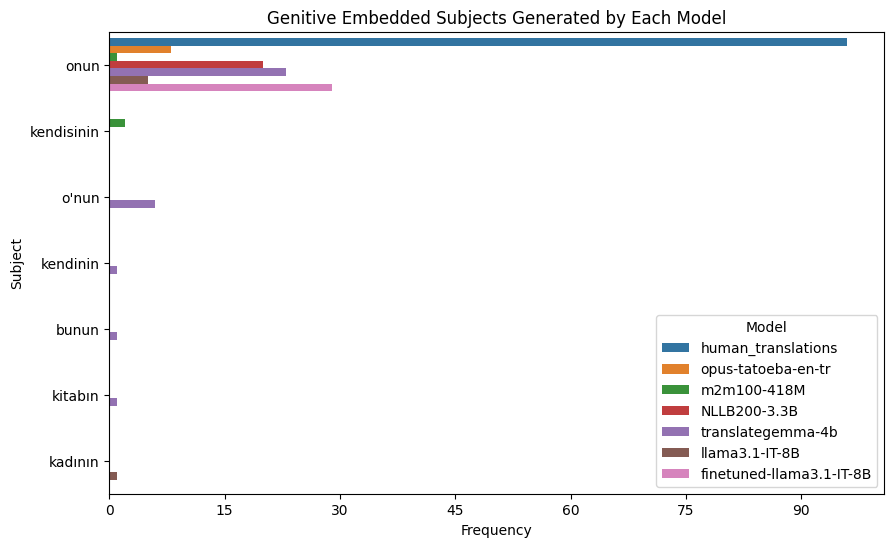

In [20]:
import matplotlib.ticker as mticker
import seaborn as sns
import matplotlib.pyplot as plt

plot_df2 = long_df_genitive.copy()  # all genitive subjects
plt.figure(figsize=(10,6))
sns.countplot(data=plot_df2, y="subject", hue="model", 
              palette="tab10")  #https://matplotlib.org/stable/gallery/color/colormap_reference.html
plt.title("Genitive Embedded Subjects Generated by Each Model")
plt.xlabel("Frequency")
plt.ylabel("Subject")
plt.legend(title="Model")

# Force integer x-axis ticks
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True)) ## Source - https://stackoverflow.com/a
# Posted by Cédric Van Rompay, modified by community. See post 'Timeline' for change history
# Retrieved 2025-12-23, License - CC BY-SA 4.0
plt.show()

# BLUE, CHR-F, COMET 

In [21]:
!pip install sacrebleu

In [22]:
import pandas as pd
import sacrebleu

In [23]:
df2 = pd.read_csv("/kaggle/input/datasets/buketsak/data-nmt-2-all3-finetuned-corrected/data_nmt_2_all3_finetuned_corrected.csv")
df3 = pd.read_csv("/kaggle/input/datasets/buketsak/data3-nmt-all-finetuned-corrected1/data3_nmt_all_finetuned_corrected1.csv")

In [24]:
datasets = {'Dataset 2': df2, 'Dataset 3': df3}
model_columns = ['opus-tatoeba-en-tr', 'm2m100-418M', 'NLLB200-3.3B', 'translategemma-4b', 'llama3.1-IT-8B', 'finetuned-llama3.1-IT-8B']

# Dictionary to store bleu scores
bleu_scores = {}

for name, df in datasets.items():
    bleu_scores[name] = {}
    references = [ref.lower() for ref in df['human_translations'].tolist()]  # list of reference sentences

    for model in model_columns:
        hypotheses = [hyp.lower() for hyp in df[model].tolist()]
        bleu = sacrebleu.corpus_bleu(hypotheses, [references])
        bleu_scores[name][model] = bleu.score

# Convert to DataFrame
bleu_df = pd.DataFrame(bleu_scores).round(2)
bleu_df

,Dataset 2,Dataset 3
opus-tatoeba-en-tr,43.56,21.77
m2m100-418M,23.85,8.12
NLLB200-3.3B,39.02,22.84
translategemma-4b,30.30,17.06
llama3.1-IT-8B,20.92,13.02
finetuned-llama3.1-IT-8B,36.11,13.70


In [25]:
# loop over datasets
for name, df in datasets.items():
    # Create a df to store sentencelevel bleu
    sentence_bleu_df = pd.DataFrame()
    
    # Add reference column
    sentence_bleu_df['human_translations'] = df['human_translations']
    
    # Compute sentencelevel bleu for each model
    for model in model_columns:
        bleu_scorer = sacrebleu.metrics.BLEU(effective_order = True, tokenize='13a')
        scores = []
        for hyp, ref in zip(df[model].tolist(), df['human_translations'].tolist()):

            # Compute sentence level bleu
            score = bleu_scorer.sentence_score(hyp, [ref]).score
            scores.append(score)
        
        # Add scores as a new column
        sentence_bleu_df[model + '_bleu'] = scores

    filename = f"{name}_sentence_level_bleu.csv"
    sentence_bleu_df.to_csv(filename, index=False)
    print(f"Saved sentence-level BLEU for {name} to {filename}")

Saved sentence-level BLEU for Dataset 2 to Dataset 2_sentence_level_bleu.csv
Saved sentence-level BLEU for Dataset 3 to Dataset 3_sentence_level_bleu.csv


# chr-F

In [26]:
# Datasets and model columns
datasets = {'Dataset 2': df2, 'Dataset 3': df3}
#model_columns = ['opus-tatoeba-en-tr', 'm2m100-418M', 'NLLB200-3.3B', 'translategemma-4b', 'llama3.1-IT-8B']

# store chrF scores in a dictionary
chrf_scores = {}

for name, df in datasets.items():
    chrf_scores[name] = {}
    
    # lowercase all 
    references = [ref.lower() for ref in df['human_translations'].tolist()]

    for model in model_columns:
        # lowercase all model outputs
        hypotheses = [hyp.lower() for hyp in df[model].tolist()]

        # compute corpus level chrF
        chrf = sacrebleu.corpus_chrf(hypotheses, [references])
        chrf_scores[name][model] = chrf.score  # chrF score in percentage

chrf_df = pd.DataFrame(chrf_scores).round(2)
chrf_df

,Dataset 2,Dataset 3
opus-tatoeba-en-tr,71.28,58.15
m2m100-418M,56.22,46.90
NLLB200-3.3B,66.12,59.48
translategemma-4b,62.84,54.50
llama3.1-IT-8B,51.88,49.39
finetuned-llama3.1-IT-8B,68.65,50.02


# Comet

In [ ]:
pip uninstall transformers torchmetrics pytorch-lightning -y

In [ ]:
!pip install transformers==4.40.2
!pip install torchmetrics==0.11.4
!pip install pytorch-lightning==2.0.9
!pip install unbabel-comet

In [1]:
from comet import download_model, load_from_checkpoint

# download model
model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(model_path)

/usr/local/lib/python3.12/dist-packages/lightning_fabric/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

hparams.yaml:   0%|          | 0.00/567 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Encoder model frozen.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:165: UserWarning: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
  rank_zero_warn(


In [27]:
datasets = {'Dataset 2': df2, 'Dataset 3': df3}
model_columns = ['opus-tatoeba-en-tr', 'm2m100-418M', 'NLLB200-3.3B', 'translategemma-4b', 'llama3.1-IT-8B', 'finetuned-llama3.1-IT-8B']
comet_scores = {}

for name, df in datasets.items():
    comet_scores[name] = {}

    sources = df['source_sentence'].tolist()
    references = df['human_translations'].tolist()

    for model in model_columns:
        hypotheses = df[model].tolist()

        data = [
            {"src": src, "mt": mt, "ref": ref}
            for src, mt, ref in zip(sources, hypotheses, references)
        ]

        model_output = comet_model.predict(data, batch_size=16)

        comet_scores[name][model] = model_output.system_score

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return [pytree], LeafSpec()
Predicting DataLoader 0: 100%|██████████| 12/12 [00:02<00:00,  5.94it/s]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return [pytree], LeafSpec()
Predicting DataLoader 0: 100%|██████████| 12/

In [28]:
comet_df = pd.DataFrame(comet_scores).round(2)
comet_df

,Dataset 2,Dataset 3
opus-tatoeba-en-tr,0.94,0.86
m2m100-418M,0.90,0.78
NLLB200-3.3B,0.93,0.89
translategemma-4b,0.91,0.88
llama3.1-IT-8B,0.88,0.82
finetuned-llama3.1-IT-8B,0.93,0.85


# DF3 evaluation

In [29]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

In [30]:
df = pd.read_csv("/kaggle/input/datasets/buketsak/data3-nmt-all-finetuned-corrected1/data3_nmt_all_finetuned_corrected1.csv")

In [31]:
# CSV cannot store lists, only strings.
# convert JSON strings to Python lists by json.loads() after reading.
model_cols = [
    "human_translations",
    "opus-tatoeba-en-tr",
    "m2m100-418M",
    "NLLB200-3.3B",
    "translategemma-4b",
    "llama3.1-IT-8B",
    "finetuned-llama3.1-IT-8B"
]

for col in model_cols:
    df[f"subject_pro_{col}"] = df[f"subject_pro_{col}"].apply(json.loads)
    df[f"pro_labels_{col}"] = df[f"pro_labels_{col}"].apply(json.loads)

In [32]:
from collections import Counter

def count_pronoun_labels(series):
    labels = []
    for lst in series:
        if isinstance(lst, list):
            labels.extend(lst)
    return Counter(labels)

In [33]:
results = {}

for col in model_cols:
    label_col = f"pro_labels_{col}"
    counts = count_pronoun_labels(df[label_col])

    results[col] = {
        "Overt (1)": counts.get("1", 0),
        "Dropped (0)": counts.get("0", 0),
        "Total": counts.get("1", 0) + counts.get("0", 0)}

In [34]:
summary_df = pd.DataFrame.from_dict(results, orient="index")
summary_df

,Overt (1),Dropped (0),Total
human_translations,208,5,213
opus-tatoeba-en-tr,154,59,213
m2m100-418M,44,169,213
NLLB200-3.3B,184,29,213
translategemma-4b,172,41,213
llama3.1-IT-8B,122,91,213
finetuned-llama3.1-IT-8B,192,21,213


In [35]:
summary_df["Overt %"] = (summary_df["Overt (1)"] / summary_df["Total"] * 100).map("{:.2f}".format)
summary_df["Dropped %"] = (summary_df["Dropped (0)"] / summary_df["Total"] * 100).map("{:.2f}".format)

summary_df

,Overt (1),Dropped (0),Total,Overt %,Dropped %
human_translations,208,5,213,97.65,2.35
opus-tatoeba-en-tr,154,59,213,72.30,27.70
m2m100-418M,44,169,213,20.66,79.34
NLLB200-3.3B,184,29,213,86.38,13.62
translategemma-4b,172,41,213,80.75,19.25
llama3.1-IT-8B,122,91,213,57.28,42.72
finetuned-llama3.1-IT-8B,192,21,213,90.14,9.86


Look what the models actually produced in nsubj positions.

In [36]:
def collect_overt_pronouns(series):
    pronouns = []
    for cell in series:
        for p in cell:
            if p != "-":
                pronouns.append(p)
    return Counter(pronouns)

In [37]:
results = {}

for col in model_cols:
    results[col] = collect_overt_pronouns(df[f"subject_pro_{col}"])

In [38]:
for model, counter in results.items():
    print(f"\n{model}")
    for pron, count in counter.most_common():
        print(f"  {pron}: {count}")


human_translations
  o: 81
  sen: 45
  ben: 44
  onlar: 19
  biz: 19

opus-tatoeba-en-tr
  ben: 37
  sen: 35
  o: 35
  biz: 14
  adam: 13
  kadın: 11
  onlar: 7
  kız: 1
  siz: 1

m2m100-418M
  ben: 19
  o: 7
  onlar: 7
  sen: 6
  biz: 4
  siz: 1

NLLB200-3.3B
  o: 49
  ben: 41
  sen: 34
  biz: 16
  onlar: 15
  kadın: 12
  erkek: 5
  kocası: 4
  karısı: 3
  adam: 3
  bizler: 1
  siz: 1

translategemma-4b
  o: 74
  ben: 40
  siz: 20
  onlar: 15
  biz: 15
  sen: 5
  her: 2
  diğer: 1

llama3.1-IT-8B
  o: 51
  ben: 34
  siz: 12
  onlar: 10
  biz: 10
  sen: 5

finetuned-llama3.1-IT-8B
  o: 78
  ben: 43
  sen: 32
  onlar: 20
  biz: 18
  siz: 1


In [39]:
def pronoun_percentages(counter):
    total = sum(counter.values())
    return {k: round(v / total * 100, 2) for k, v in counter.items()}

for model, counter in results.items():
    print(f"\n{model}")
    print(pronoun_percentages(counter))


human_translations
{'sen': 21.63, 'ben': 21.15, 'o': 38.94, 'onlar': 9.13, 'biz': 9.13}

opus-tatoeba-en-tr
{'sen': 22.73, 'ben': 24.03, 'o': 22.73, 'kadın': 7.14, 'adam': 8.44, 'biz': 9.09, 'onlar': 4.55, 'kız': 0.65, 'siz': 0.65}

m2m100-418M
{'ben': 43.18, 'o': 15.91, 'sen': 13.64, 'siz': 2.27, 'onlar': 15.91, 'biz': 9.09}

NLLB200-3.3B
{'ben': 22.28, 'o': 26.63, 'sen': 18.48, 'kadın': 6.52, 'erkek': 2.72, 'karısı': 1.63, 'kocası': 2.17, 'biz': 8.7, 'onlar': 8.15, 'adam': 1.63, 'bizler': 0.54, 'siz': 0.54}

translategemma-4b
{'ben': 23.26, 'siz': 11.63, 'sen': 2.91, 'o': 43.02, 'onlar': 8.72, 'biz': 8.72, 'her': 1.16, 'diğer': 0.58}

llama3.1-IT-8B
{'ben': 27.87, 'sen': 4.1, 'o': 41.8, 'siz': 9.84, 'onlar': 8.2, 'biz': 8.2}

finetuned-llama3.1-IT-8B
{'ben': 22.4, 'sen': 16.67, 'o': 40.62, 'onlar': 10.42, 'biz': 9.38, 'siz': 0.52}


In [40]:
counts = {}
all_pronouns = set()

# counts for each model and collect all pronouns
for col in model_cols:
    pronouns = []
    for cell in df[f"subject_pro_{col}"]:
        for p in cell:
            if p != "-":  # ignore dropped subjects
                pronouns.append(p)
    counts[col] = Counter(pronouns)
    all_pronouns.update(counts[col].keys())

#create a DataFrame from the counts
df_counts = pd.DataFrame({col: counts[col] for col in model_cols}).fillna(0).astype(int)

# sum across models to sort by total frequency
df_counts["total"] = df_counts.sum(axis=1)

df_counts = df_counts.sort_values(by="total", ascending=False).drop(columns="total")

df_counts

,human_translations,opus-tatoeba-en-tr,m2m100-418M,NLLB200-3.3B,translategemma-4b,llama3.1-IT-8B,finetuned-llama3.1-IT-8B
o,81,35,7,49,74,51,78
ben,44,37,19,41,40,34,43
sen,45,35,6,34,5,5,32
biz,19,14,4,16,15,10,18
onlar,19,7,7,15,15,10,20
siz,0,1,1,1,20,12,1
kadın,0,11,0,12,0,0,0
adam,0,13,0,3,0,0,0
erkek,0,0,0,5,0,0,0
kocası,0,0,0,4,0,0,0


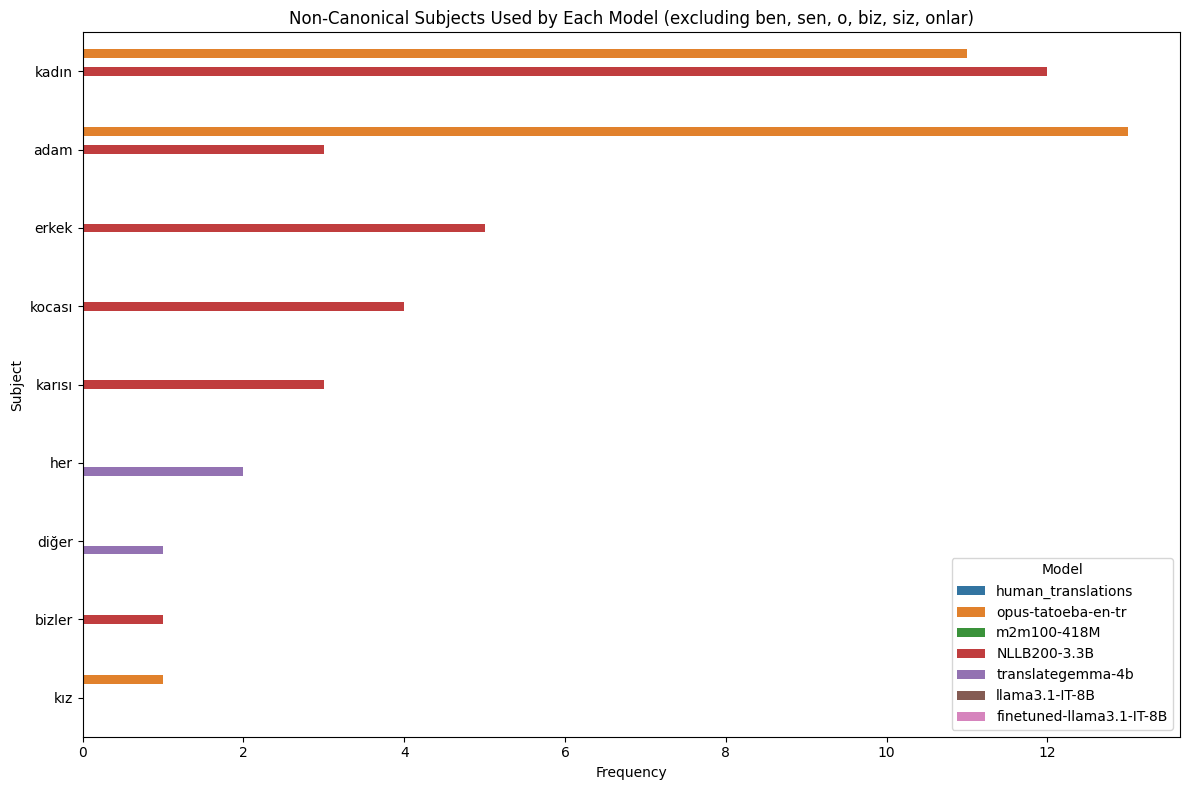

In [41]:
# canonical pronouns to exclude
exclude_pronouns = {"ben", "sen", "o", "biz", "siz", "onlar"}

#filter df_counts
other_counts = df_counts[~df_counts.index.isin(exclude_pronouns)]

#convert to long format for seaborn
plot_df = other_counts.reset_index().melt(id_vars="index", 
                                          var_name="model", 
                                          value_name="count")
plot_df = plot_df.rename(columns={"index": "subject"})
# order subjects by total frequency
subject_order = (
    plot_df.groupby("subject")["count"]
    .sum()
    .sort_values(ascending=False)
    .index
)
# Plot
plt.figure(figsize=(12,8))
sns.barplot(data=plot_df, y="subject", x="count", hue="model", order=subject_order)
plt.title("Non-Canonical Subjects Used by Each Model (excluding ben, sen, o, biz, siz, onlar)")
plt.xlabel("Frequency")
plt.ylabel("Subject")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

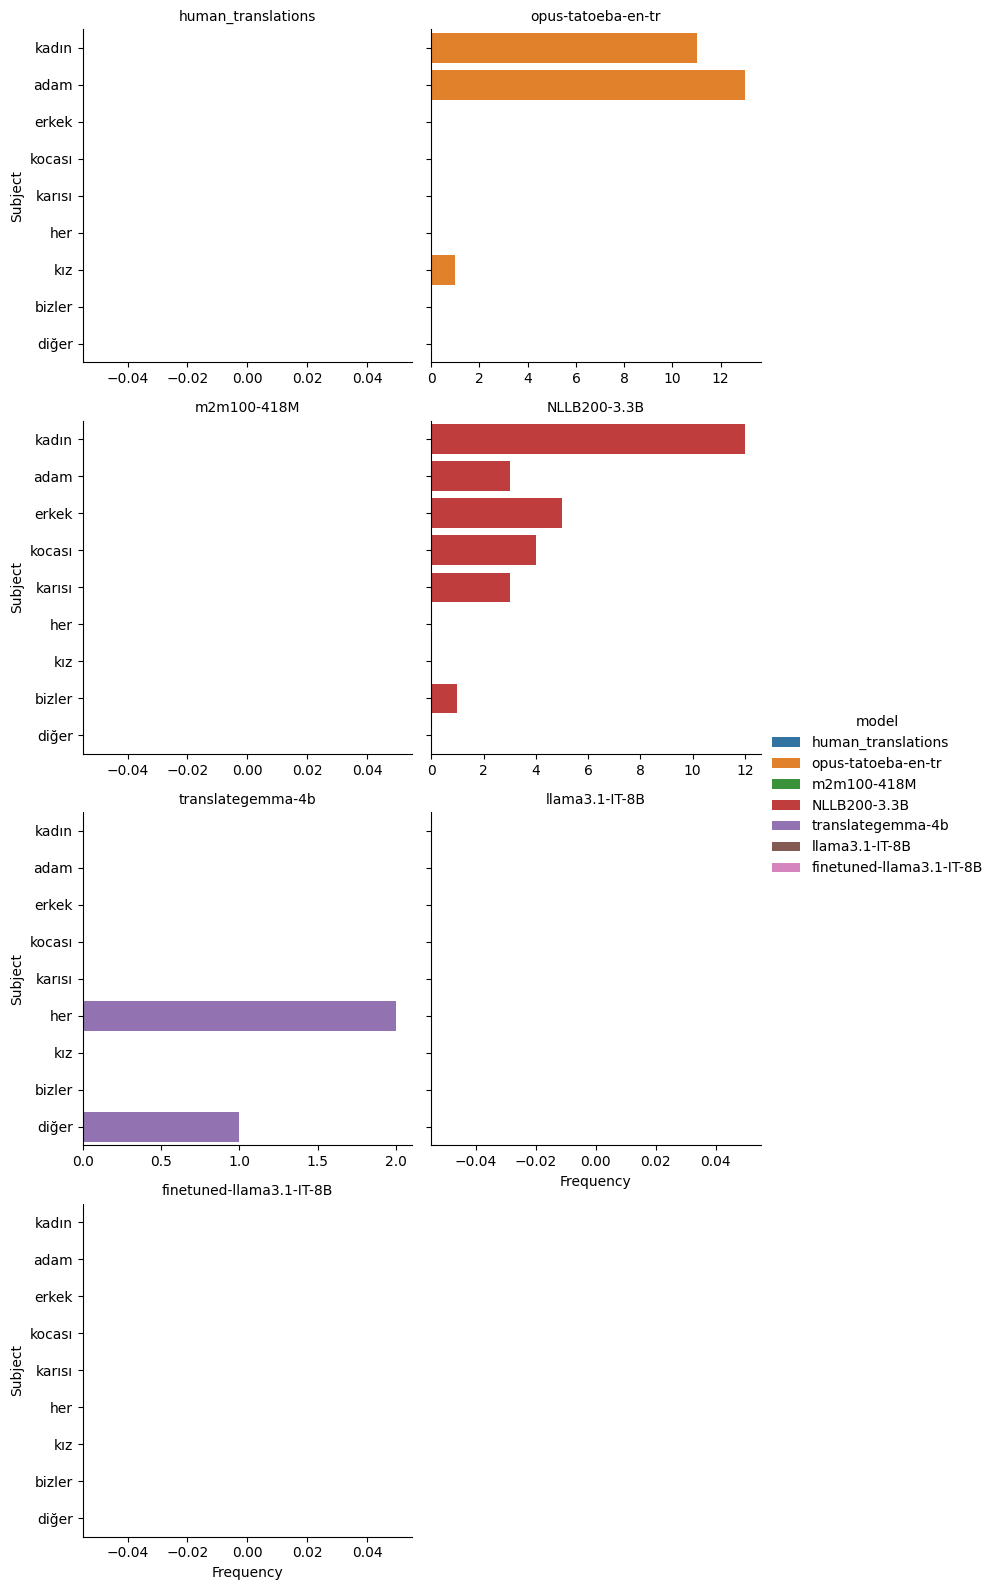

In [42]:
g = sns.catplot(
    data=plot_df, 
    y="subject", 
    x="count", 
    hue="model", 
    kind="bar",
    col="model",
    col_wrap=2,
    height=4,
    sharex=False
)
g.set_titles("{col_name}")
g.set_axis_labels("Frequency", "Subject")
plt.show()

In [43]:
#only with pronouns
PRONOUNS = ["ben", "sen", "o", "biz", "siz", "onlar"]

counts = {}
all_pronouns = set()

# gather counts for each model and collect all pronouns
for col in model_cols:
    pronouns = []
    for cell in df[f"subject_pro_{col}"]:
        for p in cell:
            if p != "-":  # ignore dropped subjects
                pronouns.append(p)
    counts[col] = Counter(pronouns)
    all_pronouns.update(counts[col].keys())


# convert to dataframe
df_counts = pd.DataFrame(counts).fillna(0).astype(int)
df_counts = df_counts.reindex(PRONOUNS)
df_counts

,human_translations,opus-tatoeba-en-tr,m2m100-418M,NLLB200-3.3B,translategemma-4b,llama3.1-IT-8B,finetuned-llama3.1-IT-8B
ben,44,37,19,41,40,34,43
sen,45,35,6,34,5,5,32
o,81,35,7,49,74,51,78
biz,19,14,4,16,15,10,18
siz,0,1,1,1,20,12,1
onlar,19,7,7,15,15,10,20


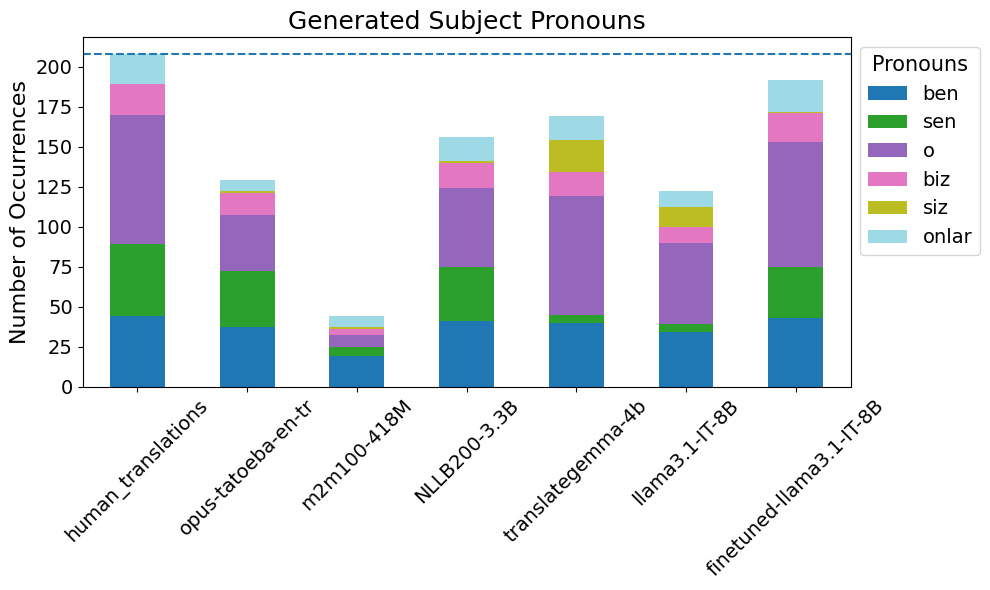

In [44]:
# Stacked bar plot, get the axes object
ax = df_counts.T.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')

# Add horizontal line (to show the gap clear)
ax.axhline(y=208, linestyle="--")

# Titles and labels
plt.title("Generated Subject Pronouns", fontsize=18)
plt.ylabel("Number of Occurrences", fontsize=16)

# Tick labels
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

# Legend
plt.legend(title="Pronouns",
           bbox_to_anchor=(1.00, 1),
           loc='upper left',
           fontsize=14,
           title_fontsize=15)

plt.tight_layout()

# Save figure
plt.savefig("comparison.png", dpi=300, bbox_inches="tight")

plt.show()

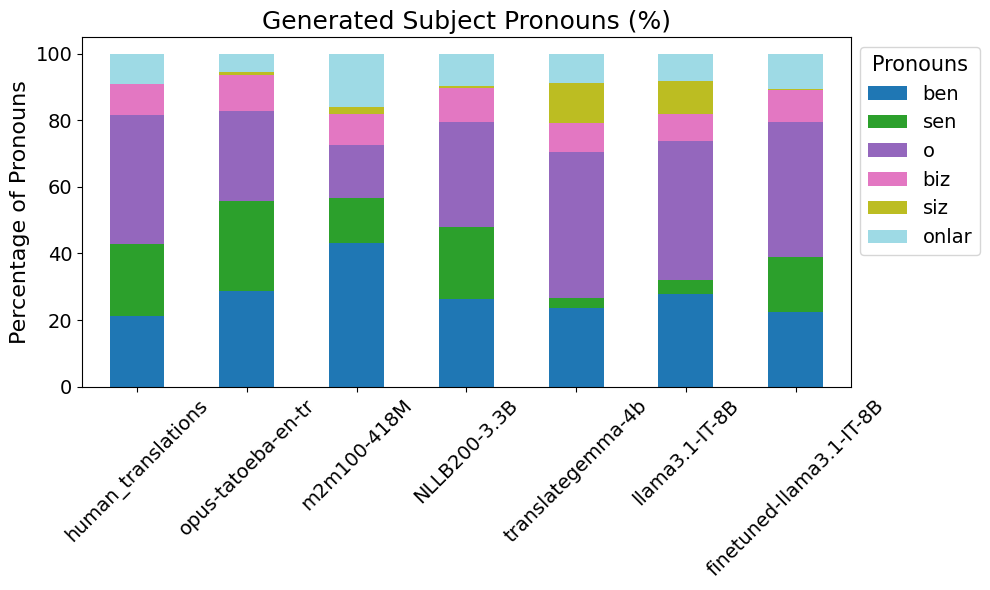

In [45]:
df_counts_pct = df_counts.div(df_counts.sum(axis=0), axis=1) * 100

# Stacked bar plot, get axes object
ax = df_counts_pct.T.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')

# Titles and labels
plt.title("Generated Subject Pronouns (%)", fontsize=18)
plt.ylabel("Percentage of Pronouns", fontsize=16)

# Tick labels
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

# Legend
plt.legend(title="Pronouns",
           bbox_to_anchor=(1.00, 1),
           loc='upper left',
           fontsize=14,
           title_fontsize=15)

plt.tight_layout()

# Save figure
plt.savefig("comparison_rate.png", dpi=300, bbox_inches="tight")

plt.show()

To do it in R -- long format

In [46]:
def long_df(df, model_cols):
    long_rows = []

    for model in model_cols:
        subj_col = f"subject_pro_{model}"
        label_col = f"pro_labels_{model}"

        for idx, (subjects, labels) in enumerate(zip(df[subj_col], df[label_col])):
            if not (isinstance(subjects, list) and isinstance(labels, list)):
                continue

            for i, label in enumerate(labels):
                subj = subjects[i] if i < len(subjects) else None

                long_rows.append({
                    "model": model,
                    "sentence_id": df.loc[idx, "sentence_id"],
                    "pronoun": subj if subj != "-" else None,
                    "subject_type": "overt" if label == "1" else "dropped"
                })

    return pd.DataFrame(long_rows)

long_df3 = long_df(df, model_cols)
long_df3.to_csv("long_df3_subjects.csv", index=False)
long_df3.head()

,model,sentence_id,pronoun,subject_type
0,human_translations,1,sen,overt
1,human_translations,1,ben,overt
2,human_translations,2,sen,overt
3,human_translations,2,ben,overt
4,human_translations,3,sen,overt


In [47]:
PRONOUNS = {"ben", "sen", "o", "biz", "siz", "onlar"}

rows = []

for model in model_cols:
    if model == "human_translations":
        continue

    for idx, (human_list, model_list) in enumerate(
        zip(df["subject_pro_human_translations"], df[f"subject_pro_{model}"])
    ):
        if not (isinstance(human_list, list) and isinstance(model_list, list)):
            continue

        for i in range(min(len(human_list), len(model_list))):
            gold = human_list[i]
            pred = model_list[i]

            # only evaluate overt pronouns
            if gold in PRONOUNS and pred in PRONOUNS:
                rows.append({
                    "model": model,
                    "gold": gold,
                    "pred": pred
                                    })

eval_df = pd.DataFrame(rows)
eval_df.head()

,model,gold,pred
0,opus-tatoeba-en-tr,sen,sen
1,opus-tatoeba-en-tr,ben,ben
2,opus-tatoeba-en-tr,sen,sen
3,opus-tatoeba-en-tr,ben,ben
4,opus-tatoeba-en-tr,o,o


In [48]:
#pronouns
PRONOUNS = {"ben", "sen", "o", "biz", "siz", "onlar"}

# Build evaluation dataframe
rows = []
for model in model_cols:
    if model == "human_translations":
        continue

    for idx, (gold_list, pred_list) in enumerate(
        zip(df["subject_pro_human_translations"], df[f"subject_pro_{model}"])
    ):
        if not (isinstance(gold_list, list) and isinstance(pred_list, list)):
            continue

        for i in range(min(len(gold_list), len(pred_list))):
            gold = gold_list[i] if gold_list[i] is not None else "-"   # mark nulls
            pred = pred_list[i] if pred_list[i] is not None else "-"

            rows.append({
                "model": model,
                "gold": gold,
                "pred": pred
            })

eval_df = pd.DataFrame(rows)

# Function to convert token to behavior
def pronoun_behavior(x):
    if x == "-":
        return "Dropped"
    else:
        return "Overt"  # includes pronouns and all other words

# Overt vs Dropped evaluation
print(" Overt vs Dropped Evaluation")

for model in eval_df["model"].unique():
    sub = eval_df[eval_df["model"] == model]

    gold_behavior = sub["gold"].apply(pronoun_behavior)
    pred_behavior = sub["pred"].apply(pronoun_behavior)

    print(f"\n{model}")
    print("Accuracy (Overt vs Dropped):", accuracy_score(gold_behavior, pred_behavior))
    print(classification_report(
        gold_behavior,
        pred_behavior,
        labels=["Overt", "Dropped"],
        zero_division=0 ))

 Overt vs Dropped Evaluation

opus-tatoeba-en-tr
Accuracy (Overt vs Dropped): 0.7464788732394366
              precision    recall  f1-score   support

       Overt       1.00      0.74      0.85       208
     Dropped       0.08      1.00      0.16         5

    accuracy                           0.75       213
   macro avg       0.54      0.87      0.50       213
weighted avg       0.98      0.75      0.83       213


m2m100-418M
Accuracy (Overt vs Dropped): 0.2300469483568075
              precision    recall  f1-score   support

       Overt       1.00      0.21      0.35       208
     Dropped       0.03      1.00      0.06         5

    accuracy                           0.23       213
   macro avg       0.51      0.61      0.20       213
weighted avg       0.98      0.23      0.34       213


NLLB200-3.3B
Accuracy (Overt vs Dropped): 0.8873239436619719
              precision    recall  f1-score   support

       Overt       1.00      0.88      0.94       208
     Dropped     

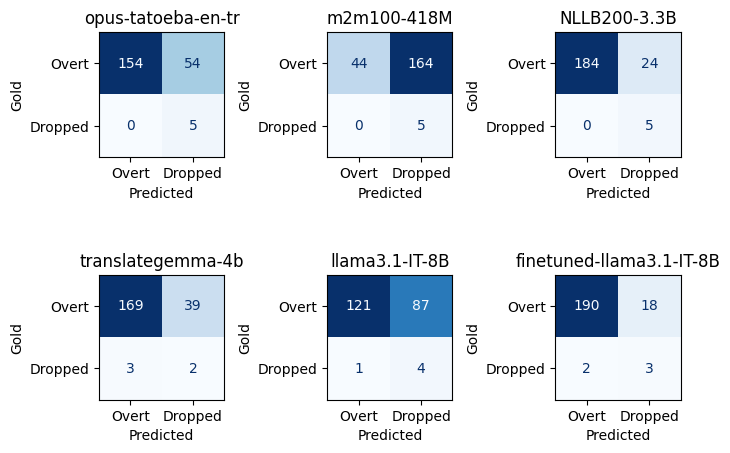

In [49]:
# confusion matrix plotting
models = eval_df["model"].unique()
n = len(models)

#  grid size
cols = 3
rows = 3

fig, axes = plt.subplots(rows, cols, figsize=(7, 7))
axes = axes.flatten()

for ax, model in zip(axes, models):
    sub = eval_df[eval_df["model"] == model]

    gold_behavior = sub["gold"].apply(pronoun_behavior)
    pred_behavior = sub["pred"].apply(pronoun_behavior)

    cm = confusion_matrix(
        gold_behavior,
        pred_behavior,
        labels=["Overt", "Dropped"]
    )
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Overt", "Dropped"]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_title(model)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Gold")

# Remove empty subplots
for i in range(len(models), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [50]:
# pronoun-level evaluation (only overt pronouns)
print("\nPronoun-level Accuracy")

overt_df = eval_df[eval_df["gold"] != "-"]  # only consider overt gold pronouns

for model in overt_df["model"].unique():
    sub = overt_df[overt_df["model"] == model]

    print(f"\n {model}")
    print("Accuracy (Pronouns only):", accuracy_score(sub["gold"], sub["pred"]))
    print(classification_report(
        sub["gold"],
        sub["pred"],
        labels=sorted(PRONOUNS),
        zero_division=0
    ))


Pronoun-level Accuracy

 opus-tatoeba-en-tr
Accuracy (Pronouns only): 0.6153846153846154
              precision    recall  f1-score   support

         ben       1.00      0.84      0.91        44
         biz       1.00      0.74      0.85        19
           o       1.00      0.43      0.60        81
       onlar       1.00      0.37      0.54        19
         sen       1.00      0.78      0.88        45
         siz       0.00      0.00      0.00         0

   micro avg       0.99      0.62      0.76       208
   macro avg       0.83      0.53      0.63       208
weighted avg       1.00      0.62      0.74       208


 m2m100-418M
Accuracy (Pronouns only): 0.20673076923076922
              precision    recall  f1-score   support

         ben       1.00      0.43      0.60        44
         biz       1.00      0.21      0.35        19
           o       1.00      0.09      0.16        81
       onlar       1.00      0.37      0.54        19
         sen       1.00      0.13   

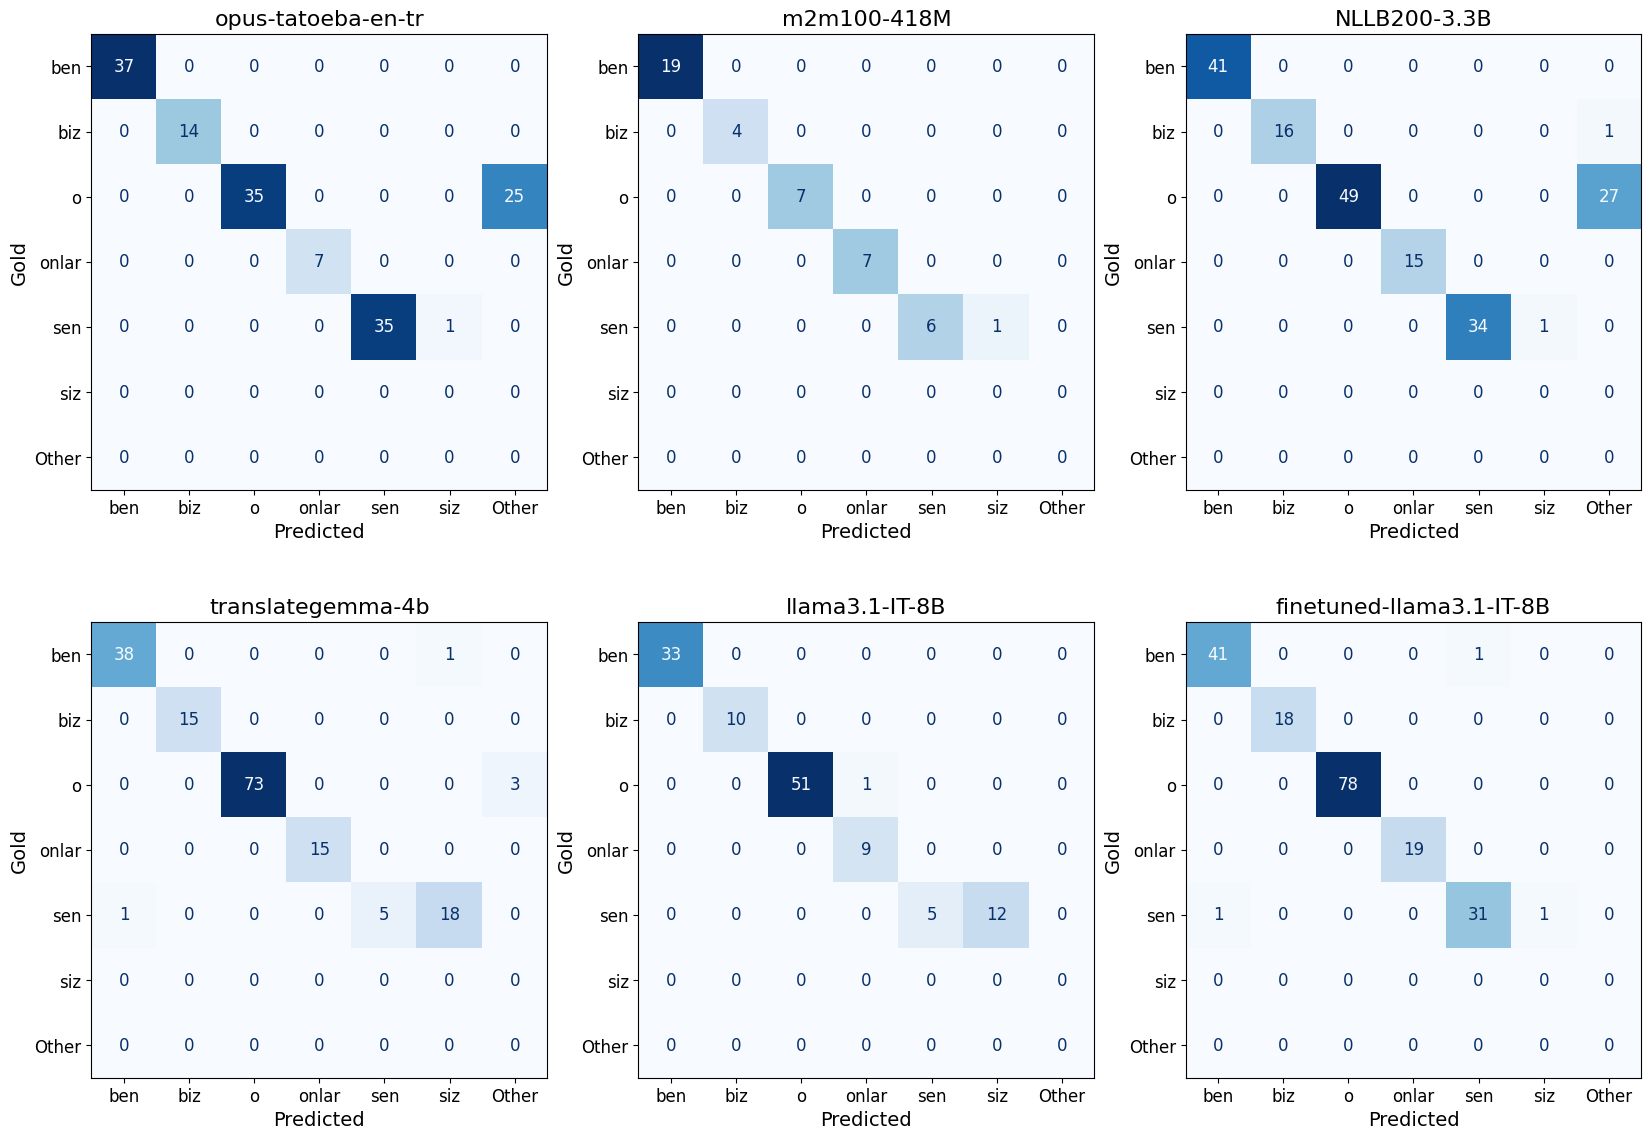

In [51]:
rows = []
for model in model_cols:
    if model == "human_translations":
        continue

    for gold_list, pred_list in zip(df["subject_pro_human_translations"], df[f"subject_pro_{model}"]):
        if not (isinstance(gold_list, list) and isinstance(pred_list, list)):
            continue

        for i in range(min(len(gold_list), len(pred_list))):
            gold = gold_list[i] if gold_list[i] is not None else "-"
            pred = pred_list[i] if pred_list[i] is not None else "-"

            rows.append({
                "model": model,
                "gold": gold,
                "pred": pred
            })

eval_df = pd.DataFrame(rows)

# each pronoun, other (exclude dropped from visualization)
def token_category(x):
    if x == "-":
        return None  # exclude dropped from confusion matrix
    elif x in PRONOUNS:
        return x  # keep pronoun as label
    else:
        return "Other"

# Confusion matrix plotting for all models (overt subjects only)
models = eval_df["model"].unique()
n = len(models)
cols = 3
rows = 2
fig, axes = plt.subplots(rows, cols, figsize=(20, 14))
axes = axes.flatten()

# Sorted pronouns + other
labels = sorted(PRONOUNS) + ["Other"]

for ax, model in zip(axes, models):
    sub = eval_df[eval_df["model"] == model]

    gold_cat = sub["gold"].apply(token_category)
    pred_cat = sub["pred"].apply(token_category)

    # keep only overt subjects (exclude dropped)
    mask = gold_cat.notna() & pred_cat.notna()
    gold_cat = gold_cat[mask]
    pred_cat = pred_cat[mask]

    cm = confusion_matrix(
        gold_cat,
        pred_cat,
        labels=labels)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d")

    # Make labels clearer
    ax.set_title(model, fontsize=16)
    ax.set_xlabel("Predicted", fontsize=14)
    ax.set_ylabel("Gold", fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)

    # Increase numbers inside cells
    for text in ax.texts:
        text.set_fontsize(12)

# Remove empty subplots
for i in range(len(models), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout
plt.savefig(
    "confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"

)
plt.show()